Necessary Imports

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

Loading Dataframe:

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Ai and ML/Week2/Iris.csv") # changed to read_csv and the correct file name

Step 2: Dataset Information

In [ ]:
print ("Dataset Preview:")
print (df.head()) # Show first 5 rows
print ("\nDataset Information:")
print(df.info()) # Summary of dataset

Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
mem

Step 3: Extract features (X) and target labels (y)

In [ ]:
X = df.iloc[:, 1 :- 1]. values # All columns except the first and the last one (features) since the first column is an index
y = df. iloc[:, -1]. values # Last column (target)

Step 4: Convert categorical labels to numeric

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # Convert labels to integers (0,1,2)

Step 5: One-Hot Encode the Labels

In [ ]:
one_hot_encoder = OneHotEncoder (sparse_output=False) #changed sparse to sparse_output and set to False
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))

Display results

In [ ]:
print("nUnique Classes:", np.unique(y))
print("Encoded Labels:", np.unique(y_encoded))
print ("One-Hot Encoded Labels:\n", y_one_hot [:5]) # Show first 5

nUnique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Labels: [0 1 2]
One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Step 6: Split dataset into training (80%) and testing (20%) sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42, stratify
=y_one_hot)

Output shapes

In [ ]:
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test. shape)
import numpy as np
def softmax(z):
  z_shifted = z - np.max(z, axis=1, keepdims=True)
  exp_z = np.exp(z_shifted)
  return exp_z / np.sum(exp_z, axis=1, keepdims=True)





Shapes:
X_train: (120, 4) y_train: (120, 3)
X_test: (30, 4) y_test: (30, 3)


In [ ]:
def loss_softmax(y_pred, y):
  epsilon = 1e-12 # To avoid log(0)
  y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon) # Prevent log(0) by clipping values
  n = y. shape [0] # Number of samples
  loss =- np.sum(y*np.log(y_pred)) /n
  return loss

In [ ]:
def cost_softmax(X, y, W, b):
  n = X.shape [0] # Number of samples
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  cost = loss_softmax(y_pred, y)
  return cost

In [ ]:
def compute_gradient_softmax(x, y, W, b):
  n, d = x.shape
  z = np.dot(x, W) + b
  y_pred = softmax(z)
  grad_W = np.dot(x.T, (y_pred - y)) / n
  grad_b = np.sum(y_pred - y, axis=0) / n
  return grad_W, grad_b

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
  cost_history = []
  for i in range(n_iter):
    # Compute gradients
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

    # Update weights and biases using the gradients
    W -= alpha * grad_W
    b -= alpha * grad_b

    # Compute and store cost
    cost = cost_softmax(X, y, W, b)
    cost_history.append(cost)

    # Print cost at regular intervals
    if show_cost and (i % 100 == 0 or i == n_iter - 1):
      print(f"Iteration {i}: Cost = {cost:.6f}")
  return W, b, cost_history

In [ ]:
def predict_softmax(X, W, b):
  z = np.dot(X, W) + b # Compute the scores (logits)
  y_pred = softmax(z) # Get the probabilities using the softmax function

  # Assign the class with the highest probability
  predicted_classes = np.argmax(y_pred, axis=1)
  return predicted_classes

Iteration 0: Cost = 1.042593
Iteration 100: Cost = 0.473559
Iteration 200: Cost = 0.265773
Iteration 300: Cost = 0.222745
Iteration 400: Cost = 0.195352
Iteration 500: Cost = 0.176197
Iteration 600: Cost = 0.162005
Iteration 700: Cost = 0.151041
Iteration 800: Cost = 0.142297
Iteration 900: Cost = 0.135149
Iteration 999: Cost = 0.129241


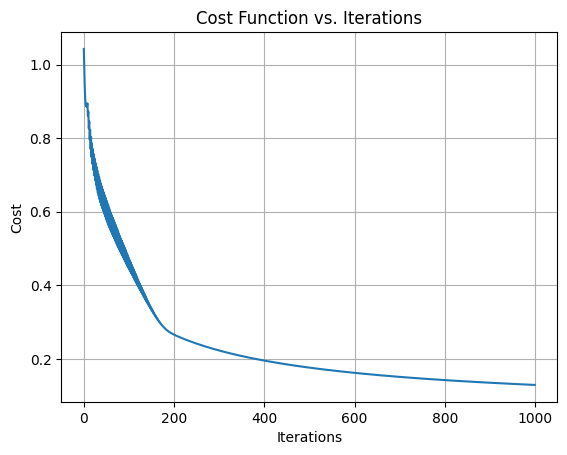

In [ ]:
import matplotlib.pyplot as plt
# Initialize the weights and biases
d = X_train. shape [1] # Number of features
c = y_train. shape [1] # Number of classes
W = np.random.randn(d, c) * 0.01 # Small random weights
b = np.zeros(c) # Bias initialized to 0
# Set hyperparameters
alpha = 0.1 # Learning rate
n_iter = 1000 # Number of iterations
# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)
# Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel ('Cost')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
# Evaluation Function
def evaluate_classification(y_true, y_pred) :
  '''
  Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

  Parameters:
  y_true (numpy.ndarray): True labels
  y_pred (numpy.ndarray): Predicted labels

  Returns:
  tuple: Confusion matrix, precision, recall, F1 score'''

  # Compute confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # Compute precision, recall, and F1-score
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return cm, precision, recall, f1

In [ ]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1) # True labels in numeric form
# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
